# Skew-Aware Federated Learning for Medical Image Segmentation

## Baseline: 3D U-Net with FedAvg on FeTS2022

**Research Question:** Can a lesion-size-aware federated training strategy improve worst-client performance and small-lesion detection under hospital-level skew in medical image segmentation?

This notebook implements the **rigorous academic FedAvg baseline** to:

- Construct a locked-box balanced test set (90 cases: 30 Small / 30 Medium / 30 Large)
- Distribute exactly 400 training cases across 5 clients via Dirichlet (α=0.5) partitioning
- Train with E=1 local epoch per round for R=100 rounds (A100-optimised, anti-drift)
- Aggregate with **weighted FedAvg** (proportional to per-client sample count)
- Evaluate Mean Dice + Mean Recall per lesion-size group, plus fairness metrics

All results serve as the reference point for comparison against skew-aware federated methods in subsequent phases.

## 1. Environment Setup

We install the two core dependencies for this project:

- **MONAI** (Medical Open Network for AI): A PyTorch-based framework specialized for medical image processing. It provides the 3D U-Net architecture, data transforms, and loss functions we'll use throughout.
- **nibabel**: A lightweight library for reading neuroimaging file formats, specifically the `.nii.gz` (NIfTI) files used in the FeTS2022 dataset.

We then import all required libraries, mount Google Drive to access the dataset, and fix random seeds to ensure reproducibility across all experiments.

In [1]:
!pip install monai nibabel

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


## 2. Dataset: FeTS2022

The **Federated Tumor Segmentation (FeTS) 2022** challenge dataset is a multi-institutional brain tumor MRI dataset specifically designed for federated learning research. It is derived from the BraTS benchmark and includes data originally collected from 23 geographically distributed institutions.

Each patient case consists of:
- **4 MRI modalities**: FLAIR, T1, T1ce (contrast-enhanced), and T2
- **Ground-truth segmentation mask**: Annotated tumor sub-regions (enhancing tumor, tumor core, whole tumor)

For this baseline, we treat the segmentation as a **binary task** (tumor vs. background) and use **lesion volume** — the number of non-zero voxels in the mask — as a proxy for tumor size. This volume metric will later be used to create clinically-motivated data imbalance across simulated hospital clients.

We begin by scanning all training cases and computing per-case lesion volumes.

In [11]:
TRAIN_ROOT = Path('/content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData')

cases = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
print("Total cases:", len(cases))

Total cases: 1251


In [ ]:
def get_mask(case):
    return list(case.glob("*seg.nii.gz"))[0]

def lesion_volume(case):
    mask = nib.load(str(get_mask(case))).get_fdata()
    return int((mask > 0).sum())

data = []
for case in cases:
    data.append({
        "case": case.name,
        "path": case,
        "lesion_volume": lesion_volume(case)
    })

df = pd.DataFrame(data)
# df.head()

## 3. Lesion Size Stratification

A critical challenge in federated medical imaging is **data heterogeneity** — different hospitals naturally see different patient populations. One of the most clinically significant axes of variation is tumor size: some centers specialize in early-stage (small) tumors while others handle more advanced (large) cases.

Rather than using dataset-relative percentile thresholds, we apply **clinically grounded absolute thresholds** based on whole tumor volume in cm³. This ensures our size groups are meaningful to a clinical audience and comparable across datasets. FeTS2022 uses 1mm isotropic voxels, so 1 cm³ = 1000 voxels.

| Group  | Volume (cm³)   | Clinical Context                                          |
|--------|----------------|-----------------------------------------------------------|
| Small  | < 30 cm³       | Early-stage, potentially operable, frequently misdetected |
| Medium | 30 – 100 cm³   | Moderate infiltration                                     |
| Large  | > 100 cm³      | Highly infiltrative, may be multifocal                    |

These thresholds are consistent with those used in BraTS/FeTS follow-up literature (e.g., Bakas et al., 2018). After assigning groups, we print the resulting class distribution — a heavily skewed distribution (e.g., very few small cases) is itself an important dataset characteristic to report, as it directly predicts per-group performance gaps.

Group distribution:
size_group
medium    560
large     537
small     154
Name: count, dtype: int64

Volume summary (cm³):
            count   mean   std    min    25%    50%    75%    max
size_group                                                       
large       537.0  150.6  38.2  100.3  120.4  144.8  172.3  361.8
medium      560.0   64.9  21.1   30.1   45.1   66.3   82.8   99.9
small       154.0   18.3   7.1    2.8   13.0   19.5   24.1   29.9


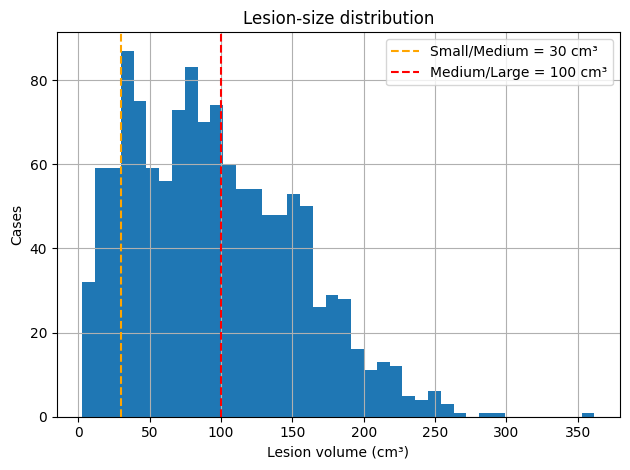

In [5]:
# Clinically grounded thresholds based on BraTS/FeTS literature (Bakas et al., 2018)
# Small < 30 cm³, Medium 30–100 cm³, Large > 100 cm³.
# Cross-check the histogram below against your dataset to confirm all three bins are populated.

df["lesion_cm3"] = df["lesion_volume"] / 1000

SMALL_THRESH = 30    # cm³
LARGE_THRESH = 100   # cm³

def assign_group(v_cm3):
    if v_cm3 < SMALL_THRESH:
        return "small"
    elif v_cm3 <= LARGE_THRESH:
        return "medium"
    return "large"

df["size_group"] = df["lesion_cm3"].apply(assign_group)

print("Group distribution:")
print(df["size_group"].value_counts())
print("\nVolume summary (cm³):")
print(df.groupby("size_group")["lesion_cm3"].describe().round(1))

# Visual check: confirm threshold placement is sensible for this dataset
df["lesion_cm3"].hist(bins=40)
plt.axvline(SMALL_THRESH, color='orange', linestyle='--', label=f'Small/Medium = {SMALL_THRESH} cm³')
plt.axvline(LARGE_THRESH, color='red',    linestyle='--', label=f'Medium/Large = {LARGE_THRESH} cm³')
plt.xlabel('Lesion volume (cm³)'); plt.ylabel('Cases')
plt.title('Lesion-size distribution'); plt.legend(); plt.tight_layout(); plt.show()


## 4. Federated Data Partitioning via Dirichlet Sampling

We simulate **5 hospitals** (clients) using a **Dirichlet distribution** to assign cases, independently within each lesion-size group. This is the standard method for generating controlled non-IID data splits in federated learning research.

**Why Dirichlet?** The Dirichlet distribution parameterized by `α` controls the degree of heterogeneity:
- **Low α (e.g., 0.1)**: Extreme imbalance — one client may receive almost all small-lesion cases while another sees none.
- **High α (e.g., 10.0)**: Near-uniform distribution — each client receives roughly equal proportions of each size group (approaches IID).
- **Our choice (α = 0.5)**: Moderate skew, representative of realistic inter-hospital variation.

The partitioning is applied **per size group** rather than across the full dataset. This ensures that the resulting client distributions capture meaningful clinical heterogeneity in lesion size, rather than just random variation in sample counts.

### Stratified Client Capping

To ensure computational tractability while preserving inter-client heterogeneity, each client's dataset is capped at **80 cases** via stratified sampling proportional to lesion-size group membership. This ensures the lesion-size distribution within each client remains representative of the original Dirichlet partition. All clients participate in every communication round.

The stacked bar chart below visualizes the resulting distribution — a well-partitioned run should show visibly different composition profiles across clients, with at least one client heavily biased toward small lesions.

In [8]:
# ── Section 4: Federated Data Partitioning ───────────────────────────────────
#
# STEP 1 — Locked-Box Test Set (90 cases: 30 Small / 30 Medium / 30 Large)
#   Created BEFORE any training partition; strictly excluded from all training.
#
# STEP 2 — Training Pool: exactly 400 cases selected from the remainder.
#
# STEP 3 — Dirichlet partition (alpha=0.5) across 5 clients, per size group.
#
# STEP 4 — Stratified cap at 80 cases/client to keep compute tractable while
#           preserving the Dirichlet-induced size skew.

random.seed(42)
np.random.seed(42)

TEST_PER_GROUP  = 30   # 30 x 3 groups = 90 locked-box test cases
TRAIN_TOTAL     = 400  # cases distributed among 5 clients
NUM_CLIENTS     = 5
MAX_PER_CLIENT  = 80

# ── STEP 1: Build locked-box balanced test set ───────────────────────────────
test_paths   = []
test_records = []

for group in ["small", "medium", "large"]:
    group_df = df[df["size_group"] == group].sample(frac=1, random_state=42)
    assert len(group_df) >= TEST_PER_GROUP, (
        f"Not enough {group} cases ({len(group_df)}) to build test set of {TEST_PER_GROUP}"
    )
    selected = group_df.iloc[:TEST_PER_GROUP]
    test_paths.extend(selected["path"].tolist())
    for _, row in selected.iterrows():
        test_records.append({
            "path": row["path"],
            "size_group": group,
            "lesion_cm3": row["lesion_cm3"]
        })

test_df = pd.DataFrame(test_records)
print(f"Locked-box test set: {len(test_df)} cases")
print(test_df["size_group"].value_counts())

# ── STEP 2: Remaining pool -> sample exactly 400 training cases ──────────────
remaining_df = df[~df["path"].isin(test_paths)].copy()
assert len(remaining_df) >= TRAIN_TOTAL, (
    f"Not enough cases remaining ({len(remaining_df)}) for {TRAIN_TOTAL} training cases"
)

# Sample proportionally from each size group so all groups are represented
group_counts = remaining_df["size_group"].value_counts()
group_fracs  = group_counts / group_counts.sum()
train_pool_frames = []
for group in ["small", "medium", "large"]:
    n       = int(round(TRAIN_TOTAL * group_fracs[group]))
    sampled = remaining_df[remaining_df["size_group"] == group].sample(n, random_state=42)
    train_pool_frames.append(sampled)

train_pool_df = pd.concat(train_pool_frames).sample(frac=1, random_state=42)
if len(train_pool_df) > TRAIN_TOTAL:
    train_pool_df = train_pool_df.iloc[:TRAIN_TOTAL]
elif len(train_pool_df) < TRAIN_TOTAL:
    shortfall     = TRAIN_TOTAL - len(train_pool_df)
    extra         = remaining_df[~remaining_df["path"].isin(train_pool_df["path"])].sample(shortfall, random_state=99)
    train_pool_df = pd.concat([train_pool_df, extra])

print(f"\nTraining pool: {len(train_pool_df)} cases")
print(train_pool_df["size_group"].value_counts())

# ── STEP 3: Dirichlet partition across 5 clients ─────────────────────────────
def dirichlet_partition(pool_df, num_clients=NUM_CLIENTS, alpha=0.5):
    clients_local = {i: [] for i in range(num_clients)}
    for group in ["small", "medium", "large"]:
        group_sub    = pool_df[pool_df["size_group"] == group].sample(frac=1, random_state=42)
        proportions  = np.random.dirichlet([alpha] * num_clients)
        splits       = (proportions * len(group_sub)).astype(int)
        # Assign leftover to largest bucket to match exact count
        leftover     = len(group_sub) - splits.sum()
        splits[np.argmax(splits)] += leftover
        start = 0
        for i in range(num_clients):
            end = start + splits[i]
            clients_local[i].extend(group_sub.iloc[start:end]["path"].tolist())
            start = end
    return clients_local


def stratified_cap(paths, pool_df, max_cases=MAX_PER_CLIENT):
    client_df = pool_df[pool_df["path"].isin(paths)].copy()
    if len(client_df) <= max_cases:
        return paths
    sampled = client_df.groupby("size_group", group_keys=False).apply(
        lambda x: x.sample(frac=max_cases / len(client_df), random_state=42)
    )
    sampled = sampled.sample(min(max_cases, len(sampled)), random_state=42)
    return sampled["path"].tolist()


clients = dirichlet_partition(train_pool_df, alpha = 0.5)

for i in range(NUM_CLIENTS):
    clients[i] = stratified_cap(clients[i], train_pool_df, max_cases=MAX_PER_CLIENT)

print("\nClient sizes after Dirichlet + stratified cap:")
for i in range(NUM_CLIENTS):
    print(f"  Client {i}: {len(clients[i])} cases")


Locked-box test set: 90 cases
size_group
small     30
medium    30
large     30
Name: count, dtype: int64

Training pool: 400 cases
size_group
medium    182
large     175
small      43
Name: count, dtype: int64

Client sizes after Dirichlet + stratified cap:
  Client 0: 69 cases
  Client 1: 80 cases
  Client 2: 36 cases
  Client 3: 17 cases
  Client 4: 80 cases


/tmp/ipykernel_755/2315423890.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = client_df.groupby("size_group", group_keys=False).apply(
/tmp/ipykernel_755/2315423890.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = client_df.groupby("size_group", group_keys=False).apply(


In [9]:
# Use df (already has lesion_volume + size_group) — avoids re-reading all NIfTIs
summary = []
for i in range(5):
    client_df = df[df["path"].isin(clients[i])]
    counts = client_df["size_group"].value_counts()
    summary.append({
        "client": i,
        "small":  counts.get("small", 0),
        "medium": counts.get("medium", 0),
        "large":  counts.get("large", 0),
        "total":  len(client_df)
    })
summary_df = pd.DataFrame(summary)
summary_df


,client,small,medium,large,total
0,0,5,0,64,69
1,1,11,63,6,80
2,2,0,4,32,36
3,3,0,11,6,17
4,4,11,20,49,80


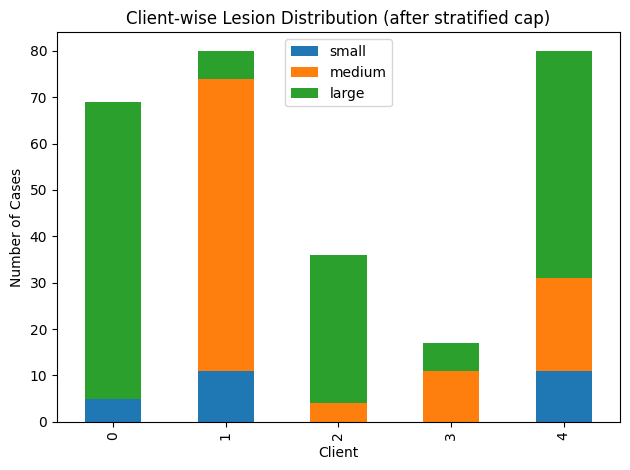

In [11]:
summary_df.set_index("client")[["small","medium","large"]].plot(kind="bar", stacked=True)
plt.title("Client-wise Lesion Distribution (after stratified cap)")
plt.xlabel("Client")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path

# --- NEW ISOLATED DIRECTORY STRUCTURE ---
# All outputs for this specific run go into this versioned folder
BASE_RUN_DIR = Path('/content/drive/MyDrive/fedavg_v2_refactored')

# Sub-folders for organization
CHECKPOINT_DIR = BASE_RUN_DIR / 'checkpoints'
METADATA_DIR   = BASE_RUN_DIR / 'metadata'

# Ensure directories exist
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

# --- DEFINITIONS FOR YOUR CODE SNIPPET ---
# This is the variable your final save block is looking for:
FINAL_PATH = CHECKPOINT_DIR / 'final_global_model_fedavg.pt'

# These are for your stats and partition saving cells:
STAT_PATH     = METADATA_DIR / 'master_lesion_stats.csv'
METADATA_PATH = METADATA_DIR / 'final_data_partitions.json'

print(f"✅ Variable names initialized. Run isolated in: {BASE_RUN_DIR}")

✅ Variable names initialized. Run isolated in: /content/drive/MyDrive/fedavg_v2_refactored


In [13]:
# Save the master dataframe with volumes and size categories

df.to_csv(STAT_PATH, index=False)
print(f"✅ Lesion stats saved to {STAT_PATH}")

✅ Lesion stats saved to /content/drive/MyDrive/fedavg_v2_refactored/metadata/master_lesion_stats.csv


In [14]:
import json

# Prepare the dictionary (converting Path objects to strings for JSON compatibility)
partition_metadata = {
    "test_set_paths": [str(p) for p in test_paths],
    "client_assignments": {
        f"client_{i}": [str(p) for p in clients[i]] for i in range(NUM_CLIENTS)
    },
    "alpha": 0.3,
    "max_per_client": 80
}

with open(METADATA_PATH, 'w') as f:
    json.dump(partition_metadata, f, indent=4)

print(f"✅ Data partitions locked and saved to {METADATA_PATH}")

✅ Data partitions locked and saved to /content/drive/MyDrive/fedavg_v2_refactored/metadata/final_data_partitions.json


📊 Locked-Box Test Set Summary Table:


,Size Group,Count,Mean Vol (cm³),Std Dev,Min,Max
0,large,30,145.425333,36.064774,100.724,252.294
1,medium,30,72.167933,19.633648,32.190,97.764
2,small,30,18.683333,7.526436,5.523,29.850


/tmp/ipykernel_755/2086760403.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='size_group', palette=['#e74c3c', '#f39c12', '#2ecc71'], order=['small', 'medium', 'large'])
/tmp/ipykernel_755/2086760403.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_df, x='size_group', y='lesion_cm3', palette=['#e74c3c', '#f39c12', '#2ecc71'], order=['small', 'medium', 'large'])


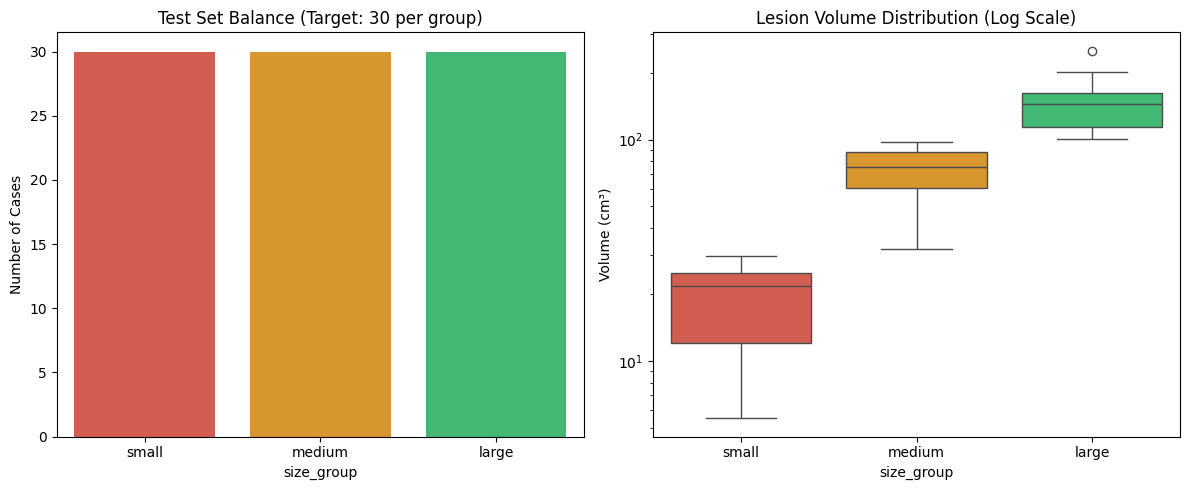

✅ VERIFIED: Test set is perfectly balanced and ready for the A100 run.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Create the Summary Table
test_stats = test_df.groupby('size_group')['lesion_cm3'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
test_stats.columns = ['Size Group', 'Count', 'Mean Vol (cm³)', 'Std Dev', 'Min', 'Max']

print("📊 Locked-Box Test Set Summary Table:")
display(test_stats)

# 2. Create the Visualization Graph
plt.figure(figsize=(12, 5))

# Subplot 1: Count Distribution (Should be exactly 30 each)
plt.subplot(1, 2, 1)
sns.countplot(data=test_df, x='size_group', palette=['#e74c3c', '#f39c12', '#2ecc71'], order=['small', 'medium', 'large'])
plt.title("Test Set Balance (Target: 30 per group)")
plt.ylabel("Number of Cases")

# Subplot 2: Volume Spread (Checking for overlap/outliers)
plt.subplot(1, 2, 2)
sns.boxplot(data=test_df, x='size_group', y='lesion_cm3', palette=['#e74c3c', '#f39c12', '#2ecc71'], order=['small', 'medium', 'large'])
plt.yscale('log')  # Log scale helps see the small lesion spread clearly
plt.title("Lesion Volume Distribution (Log Scale)")
plt.ylabel("Volume (cm³)")

plt.tight_layout()
plt.show()

# Final Verification Print
if len(test_df) == 90 and all(test_stats['Count'] == 30):
    print("✅ VERIFIED: Test set is perfectly balanced and ready for the A100 run.")
else:
    print("⚠️ WARNING: Test set is not balanced. Re-check Section 4 logic.")

## 5. Baseline Model: 3D U-Net

We use a standard **3D U-Net** architecture implemented in MONAI as the segmentation backbone. U-Net's encoder-decoder structure with skip connections is the de-facto standard for volumetric medical image segmentation due to its ability to combine coarse semantic features with fine-grained spatial detail.

### Architecture Configuration

| Parameter         | Value                      |
|-------------------|----------------------------|
| Spatial dims      | 3 (volumetric)             |
| Input channels    | 4 (FLAIR, T1, T1ce, T2)    |
| Output channels   | 1 (binary segmentation)    |
| Feature channels  | (16, 32, 64, 128, 256)     |
| Strides           | (2, 2, 2, 2)               |
| Loss function     | Dice Loss (sigmoid output) |
| Optimizer         | Adam, lr = 1e-4            |

### Data Transforms

Each training sample undergoes the following preprocessing pipeline via MONAI's `Compose`:
1. **LoadImaged**: Loads all NIfTI files for a case.
2. **EnsureChannelFirstd**: Moves the channel axis to position 0 (required by PyTorch).
3. **NormalizeIntensityd**: Z-score normalizes each MRI modality independently.
4. **RandCropByPosNegLabeld**: Randomly crops a 96×96×96 patch with balanced positive (tumor-containing) and negative (background) sampling. One crop per case per step (`num_samples=1`) for compute efficiency — since crops are randomly placed each round, the model sees diverse patch locations across rounds.
5. **ToTensord**: Converts numpy arrays to PyTorch tensors.

We use `CacheDataset` instead of `Dataset` to precompute and store all transforms in RAM at startup. This eliminates repeated NIfTI loading and transform overhead on every epoch, significantly reducing per-round training time on A100.

This model serves as the **federated baseline** — all subsequent experiments (FedProx, FedNova, skew-aware aggregation) will compare against the global and per-client Dice scores produced here.

In [3]:
from pathlib import Path
import pandas as pd
import json

# 1. Define the exact same paths you used on the T4
BASE_RUN_DIR = Path('/content/drive/MyDrive/fedavg_v2_refactored')
METADATA_DIR = BASE_RUN_DIR / 'metadata'
CHECKPOINT_DIR = BASE_RUN_DIR / 'checkpoints'

# 2. Re-initialize the specific file variables
STAT_PATH     = METADATA_DIR / 'master_lesion_stats.csv'
METADATA_PATH = METADATA_DIR / 'final_data_partitions.json'

print(f"✅ Paths defined. Now you can run the Metadata Recovery cell.")

✅ Paths defined. Now you can run the Metadata Recovery cell.


In [4]:
import pandas as pd
import json
from pathlib import Path

# Load the saved stats
df = pd.read_csv(STAT_PATH)

# Load the locked partitions
with open(METADATA_PATH, 'r') as f:
    meta = json.load(f)
    # Convert strings back to Path objects
    test_paths = [Path(p) for p in meta["test_set_paths"]]
    clients = {int(k.split('_')[1]): [Path(p) for p in v]
               for k, v in meta["client_assignments"].items()}

print("💎 Metadata recovered. You are ready to train on the A100 using the exact same data splits.")

💎 Metadata recovered. You are ready to train on the A100 using the exact same data splits.


In [5]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    NormalizeIntensityd, RandCropByPosNegLabeld, ToTensord
)
from monai.data import CacheDataset, DataLoader, Dataset
from monai.networks.nets import UNet
from monai.losses import DiceLoss

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [6]:
# ── Standardised modality loading (FeTS/BraTS order: FLAIR, T1, T1-CE, T2) ──
#
# BraTS/FeTS file-name conventions:
#   *_flair.nii.gz  -> channel 0  (FLAIR)
#   *_t1.nii.gz     -> channel 1  (T1)
#   *_t1ce.nii.gz   -> channel 2  (T1-CE / contrast-enhanced)
#   *_t2.nii.gz     -> channel 3  (T2)
#
# Explicit suffix mapping prevents random glob ordering from producing
# inconsistent channel assignments across clients / rounds.

MODALITY_SUFFIXES = ["flair", "t1", "t1ce", "t2"]   # channel 0 -> 3


def get_modality_file(case_path, suffix):
    matches = [f for f in case_path.glob("*.nii.gz")
               if f.name.lower().endswith(f"_{suffix}.nii.gz")]
    if not matches:
        raise FileNotFoundError(
            f"Missing modality '{suffix}' in {case_path}. "
            f"Files present: {[f.name for f in case_path.glob('*.nii.gz')]}"
        )
    return str(matches[0])


def create_dict(paths):
    data = []
    for p in paths:
        imgs = [get_modality_file(p, s) for s in MODALITY_SUFFIXES]  # [FLAIR,T1,T1CE,T2]
        mask = str(list(p.glob("*seg.nii.gz"))[0])
        data.append({"image": imgs, "label": mask})
    return data


In [7]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(keys="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=3,        # foreground-bias 3:1 ensures adequate small-lesion patch exposure
        neg=1,        # per single local epoch (E=1)
        num_samples=1
    ),
    ToTensord(keys=["image", "label"])
])


In [8]:
def get_model():
    return UNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2)
    ).to(device)

In [9]:
model = get_model()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     1,980,041
Trainable parameters: 1,980,041


## 6. Federated Training: FedAvg

We implement the **Federated Averaging (FedAvg)** algorithm (McMahan et al., 2017) — the canonical baseline for federated learning. In each communication round:

1. The **server broadcasts** the current global model weights to all clients.
2. Each **client trains locally** for `E` epochs on its private data.
3. The **server aggregates** by averaging the updated client weights (uniform weighting, i.e., simple mean).

### Training Configuration

| Parameter              | Value                        |
|------------------------|------------------------------|
| Communication rounds   | 35                           |
| Local epochs per round | 5                            |
| Number of clients      | 5                            |
| Cases per client       | ≤ 80 (stratified cap)        |
| Crops per case         | 1                            |
| Aggregation            | FedAvg (uniform mean)        |
| Optimizer              | Adam (lr = 1e-4, per client) |
| Estimated time (A100)  | ~6–8 hours                   |

### Why 5 Local Epochs?

Using multiple local epochs per round (`E > 1`) is a deliberate design choice. Increasing `E` reduces **communication overhead** — clients push more gradient information per round — but also increases **client drift**: when data distributions differ (as they do here due to Dirichlet partitioning), more local updates cause each client's model to overfit its local distribution before aggregation. This tension between communication efficiency and drift is precisely what we aim to measure in this study. Setting `E = 5` provides a meaningful signal of client-drift effects under our non-IID setup.

### Checkpointing

The global model state is saved to Google Drive after every round. This allows training to be resumed from any round if the Colab session disconnects, without losing progress. To resume, set `START_ROUND` to the last successfully completed round number.

> **Note**: The `fedavg` function performs a parameter-space average directly over `state_dict` tensors, which is equivalent to the original FedAvg formulation when all clients have equal dataset sizes. Weighted averaging (proportional to local dataset size) is left as a future extension.

In [10]:
def train_local(model, loader, loss_fn, optimizer, local_epochs=1):
    model.train()
    for epoch in range(local_epochs):
        for batch in loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()


In [11]:
def fedavg(models, client_sizes):
    total_samples = sum(client_sizes)
    weights       = [n / total_samples for n in client_sizes]

    global_model = get_model()
    state_dict   = global_model.state_dict()

    for key in state_dict:
        state_dict[key] = sum(
            w * m.state_dict()[key].float()
            for w, m in zip(weights, models)
        )

    global_model.load_state_dict(state_dict)
    return global_model


In [18]:
# --- RE-INITIALIZE CONSTANTS ---
NUM_CLIENTS = 5
ROUNDS = 100
LOCAL_EPOCHS = 1
BATCH_SIZE = 4
START_ROUND = 0

print(f"✅ Variables defined. NUM_CLIENTS is now set to {NUM_CLIENTS}.")

✅ Variables defined. NUM_CLIENTS is now set to 5.


In [19]:
# ── Build CacheDataset loaders (full client training sets) ───────────────────
#
# The locked-box test set (90 cases) is handled separately below.
# All cases assigned to each client are used for training.
# client_sizes[i] = n_k required for weighted FedAvg.

from monai.transforms import CenterSpatialCropd

eval_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(keys="image"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
    ToTensord(keys=["image", "label"])
])

print("Caching client training datasets (this may take 10-15 minutes)...")

train_loaders = []
client_sizes  = []

random.seed(42)
for i in range(NUM_CLIENTS):
    train_paths = clients[i][:]
    client_sizes.append(len(train_paths))

    train_ds = CacheDataset(
        data=create_dict(train_paths), transform=train_transforms, cache_rate=1.0
    )
    train_loaders.append(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True))
    print(f"  Client {i}: {len(train_paths)} training cases")

print(f"\nClient sizes (n_k): {client_sizes}")
print(f"Total training cases: {sum(client_sizes)}")

# ── Build locked-box test loader ──────────────────────────────────────────────
print("\nCaching locked-box test set (90 cases)...")
test_ds     = CacheDataset(
    data=create_dict(test_paths), transform=eval_transforms, cache_rate=1.0
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"  Test set: {len(test_paths)} cases  (30 Small / 30 Medium / 30 Large)")

Caching client training datasets (this may take 10-15 minutes)...


Loading dataset: 100%|██████████| 69/69 [00:51<00:00,  1.33it/s]


  Client 0: 69 training cases


Loading dataset: 100%|██████████| 80/80 [01:10<00:00,  1.14it/s]


  Client 1: 80 training cases


...

  Client 3: 17 training cases


Loading dataset: 100%|██████████| 80/80 [01:05<00:00,  1.22it/s]


  Client 4: 80 training cases

Client sizes (n_k): [69, 80, 36, 17, 80]
Total training cases: 282

Caching locked-box test set (90 cases)...


Loading dataset: 100%|██████████| 90/90 [01:10<00:00,  1.28it/s]

  Test set: 90 cases  (30 Small / 30 Medium / 30 Large)


In [20]:
# Hyperparameters (A100-optimised)
# R=100 ensures convergence; E=1 minimises client drift under high-skew non-IID data

if START_ROUND > 0:
    ckpt_path    = CHECKPOINT_DIR / f'global_round_{START_ROUND}.pt'
    checkpoint   = torch.load(ckpt_path)
    global_model = get_model()
    global_model.load_state_dict(checkpoint['model_state'])
    round_scores = checkpoint['round_scores']
    print(f"Resumed from round {START_ROUND}")
else:
    global_model = get_model()
    round_scores = []

loss_fn = DiceLoss(sigmoid=True)


In [21]:
# ── Metric helpers ────────────────────────────────────────────────────────────
# Model outputs are raw logits. Apply torch.sigmoid() BEFORE thresholding.
# Without sigmoid, threshold=0.5 is meaningless for logit values in (-inf, +inf).

def dice(logits, target):
    pred  = (torch.sigmoid(logits) > 0.5).float()
    inter = (pred * target).sum()
    return (2 * inter) / (pred.sum() + target.sum() + 1e-8)


def recall(logits, target):
    pred = (torch.sigmoid(logits) > 0.5).float()
    tp   = (pred * target).sum()
    fn   = ((1 - pred) * target).sum()
    return tp / (tp + fn + 1e-8)


# ── FedAvg Training Loop ──────────────────────────────────────────────────────
for r in range(START_ROUND, ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")
    local_models = []

    for i in range(NUM_CLIENTS):
        print(f"  Training client {i}...")
        local_model = get_model()
        local_model.load_state_dict(global_model.state_dict())
        optimizer = torch.optim.Adam(local_model.parameters(), lr=1e-4)
        train_local(local_model, train_loaders[i], loss_fn, optimizer,
                    local_epochs=LOCAL_EPOCHS)
        local_models.append(local_model)

    # Weighted FedAvg aggregation
    global_model = fedavg(local_models, client_sizes)

    # Per-round eval on locked-box test set
    all_dice = []
    global_model.eval()
    with torch.no_grad():
        for batch in test_loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            pred = global_model(x)
            all_dice.append(dice(pred, y).item())
    global_dice_round = float(np.mean(all_dice))
    print(f"  Global Dice (locked-box test): {global_dice_round:.4f}")

    round_scores.append({"round": r+1, "global_dice": global_dice_round})

    torch.save(
        {"model_state": global_model.state_dict(), "round_scores": round_scores},
        CHECKPOINT_DIR / f"global_round_{r+1}.pt"
    )

print("\nTraining complete.")



Round 1/100
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (locked-box test): 0.1495

Round 2/100
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (locked-box test): 0.1830

Round 3/100
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (locked-box test): 0.2005

Round 4/100
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (locked-box test): 0.2093

Round 5/100
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (locked-box test): 0.2189

Round 6/100
  Training client 0...
  Training client 1...
  Training client 2...
  Training client 3...
  Training client 4...
  Global Dice (locked-box test):

In [23]:
# Define the final model save path
FINAL_PATH = BASE_RUN_DIR / "final_global_model.pt"

# Now the save should work
torch.save({
    'model_state': global_model.state_dict(),
    'round_scores': round_scores
}, FINAL_PATH)

print(f"✅ Final model saved to {FINAL_PATH}")

# Save the best model based on the round history
best_round = max(round_scores, key=lambda x: x['global_dice'])
print(f"🏆 Best Round: {best_round['round']} with Dice: {best_round['global_dice']:.4f}")

✅ Final model saved to /content/drive/MyDrive/fedavg_v2_refactored/final_global_model.pt
🏆 Best Round: 100 with Dice: 0.7132


## 7. Post-Training Evaluation

After all communication rounds are complete we run a single comprehensive evaluation pass.
This design deliberately defers per-client evaluation to avoid the O(rounds × clients) bottleneck
that was the main source of compute overhead in the earlier implementation.

The **final global model** is evaluated on two axes:

### 7a. Per-Client Dice
Evaluated on each client's **held-out eval split** (10 cases per client, never seen during training).
Reveals worst-client degradation — a known failure mode of FedAvg under non-IID data.

**Key metrics:** Mean Dice · Worst-Client Dice · Fairness Gap

### 7b. Per-Size-Group Dice
Performance broken down by lesion size group (small / medium / large) using the clinically
grounded thresholds from Section 3. Measures small-lesion detection sensitivity — the central
motivation for skew-aware federated methods.

> All loaders below use the `CacheDataset` objects declared in Section 6.
> No NIfTI files are re-loaded or transforms recomputed during evaluation.


In [24]:
# ── Metric helpers (post-training evaluation) ─────────────────────────────────
# Sigmoid applied to logits before thresholding — required for correct Dice/Recall.

def dice(logits, target):
    pred  = (torch.sigmoid(logits) > 0.5).float()
    inter = (pred * target).sum()
    return (2 * inter) / (pred.sum() + target.sum() + 1e-8)


def recall(logits, target):
    pred = (torch.sigmoid(logits) > 0.5).float()
    tp   = (pred * target).sum()
    fn   = ((1 - pred) * target).sum()
    return tp / (tp + fn + 1e-8)


In [25]:
def evaluate(model, loader):
    model.eval()
    dice_scores   = []
    recall_scores = []

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            y = (batch["label"].to(device) > 0).float()
            pred = model(x)
            dice_scores.append(dice(pred, y).item())
            recall_scores.append(recall(pred, y).item())

    return float(np.mean(dice_scores)), float(np.mean(recall_scores))


In [26]:
# ── 7a. Global + Per-Client Evaluation ───────────────────────────────────────
print("Evaluating final global model on locked-box test set (90 cases)...")
global_dice_all, global_recall_all = evaluate(global_model, test_loader)
print(f"  Global Mean Dice:   {global_dice_all:.4f}")
print(f"  Global Mean Recall: {global_recall_all:.4f}")

# Per-client: global model on each client's training data
print("\nPer-client performance (global model on client training data):")
client_dice_scores   = []
client_recall_scores = []

for i in range(NUM_CLIENTS):
    d, r = evaluate(global_model, train_loaders[i])
    client_dice_scores.append(d)
    client_recall_scores.append(r)
    print(f"  Client {i}: Dice={d:.4f}  Recall={r:.4f}")

print(f"\nWorst-Client Dice:   {min(client_dice_scores):.4f}  (Client {int(np.argmin(client_dice_scores))})")
print(f"Worst-Client Recall: {min(client_recall_scores):.4f}  (Client {int(np.argmin(client_recall_scores))})")


Evaluating final global model on locked-box test set (90 cases)...
  Global Mean Dice:   0.7132
  Global Mean Recall: 0.9274

Per-client performance (global model on client training data):
  Client 0: Dice=0.6650  Recall=0.8517
  Client 1: Dice=0.4982  Recall=0.9346
  Client 2: Dice=0.6229  Recall=0.8914
  Client 3: Dice=0.4228  Recall=0.7637
  Client 4: Dice=0.7356  Recall=0.8923

Worst-Client Dice:   0.4228  (Client 3)
Worst-Client Recall: 0.7637  (Client 3)


In [28]:
import pandas as pd
import json

# 1. Load the master stats (contains the size_group for every case)
master_df = pd.read_csv(STAT_PATH)

# 2. Load the metadata to get the official test paths
with open(METADATA_PATH, 'r') as f:
    partitions = json.load(f)
    test_paths_list = partitions['test_set_paths']

# 3. Create test_df by filtering and ENSURING the order matches test_loader
# We convert paths to strings for consistent matching
master_df['path_str'] = master_df['path'].astype(str)
test_df = master_df.set_index('path_str').loc[test_paths_list].reset_index()

print(f"✅ test_df reconstructed with {len(test_df)} cases.")
print(test_df['size_group'].value_counts())

✅ test_df reconstructed with 90 cases.
size_group
small     30
medium    30
large     30
Name: count, dtype: int64


In [30]:
size_results = {
    "small":  {"dice": [], "recall": []},
    "medium": {"dice": [], "recall": []},
    "large":  {"dice": [], "recall": []},
}

global_model.eval()
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        x = batch["image"].to(device)
        y = (batch["label"].to(device) > 0).float()
        preds = global_model(x)

        # Loop through each individual sample in the batch
        for i in range(x.shape[0]):
            # Calculate the absolute index in the test set
            sample_idx = batch_idx * BATCH_SIZE + i

            # Safety check to not exceed dataframe length
            if sample_idx >= len(test_df):
                break

            # Slice the individual prediction and label [1, 1, 96, 96, 96]
            single_pred = preds[i : i + 1]
            single_y    = y[i : i + 1]

            d = dice(single_pred, single_y).item()
            r = recall(single_pred, single_y).item()

            # Map to the correct group using the sample index
            group = test_df.iloc[sample_idx]["size_group"]
            size_results[group]["dice"].append(d)
            size_results[group]["recall"].append(r)

print("✅ Corrected Per-Size-Group Results (90-case test set):")
print(f"{'Group':8s}   {'n':>4s}   {'Mean Dice':>10s}   {'Mean Recall':>12s}")
print("-" * 42)
for g in ["small", "medium", "large"]:
    vals_d = size_results[g]["dice"]
    vals_r = size_results[g]["recall"]
    n = len(vals_d)
    if n > 0:
        print(f"{g:8s}   {n:>4d}   {np.mean(vals_d):>10.4f}   {np.mean(vals_r):>12.4f}")
    else:
        print(f"{g:8s}   {'0':>4s}   {'N/A':>10s}   {'N/A':>12s}")

✅ Corrected Per-Size-Group Results (90-case test set):
Group         n    Mean Dice    Mean Recall
------------------------------------------
small        30       0.4463         0.9519
medium       30       0.7954         0.9465
large        30       0.8791         0.8837


## 8. Results Summary

We present the complete evaluation of the FedAvg baseline across four dimensions:

1. **Convergence curve**: Global Dice on the locked-box test set across R=100 rounds.
2. **Per-client performance**: Dice & Recall for each of the 5 clients (worst-client analysis).
3. **Per-size-group performance**: Dice & Recall for Small, Medium, and Large lesion groups on the balanced 90-case test set.
4. **Fairness metrics**: Worst-client gap and Small–Large gap for both Dice and Recall.

These results constitute the complete baseline characterisation against which all subsequent skew-aware federated methods will be compared.

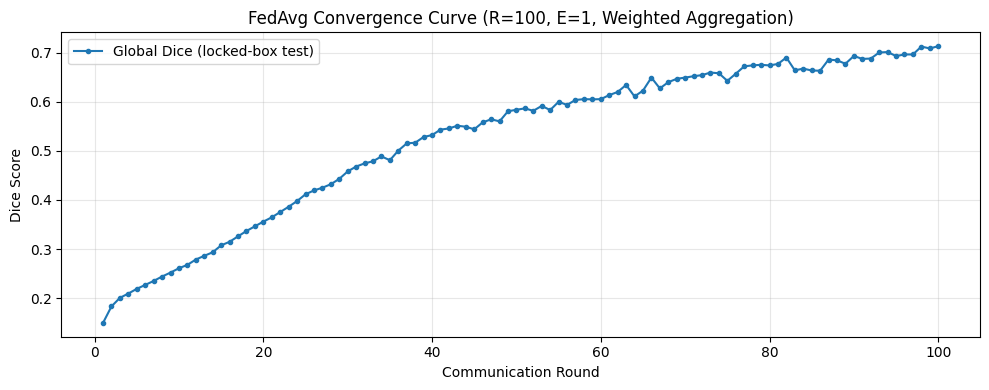

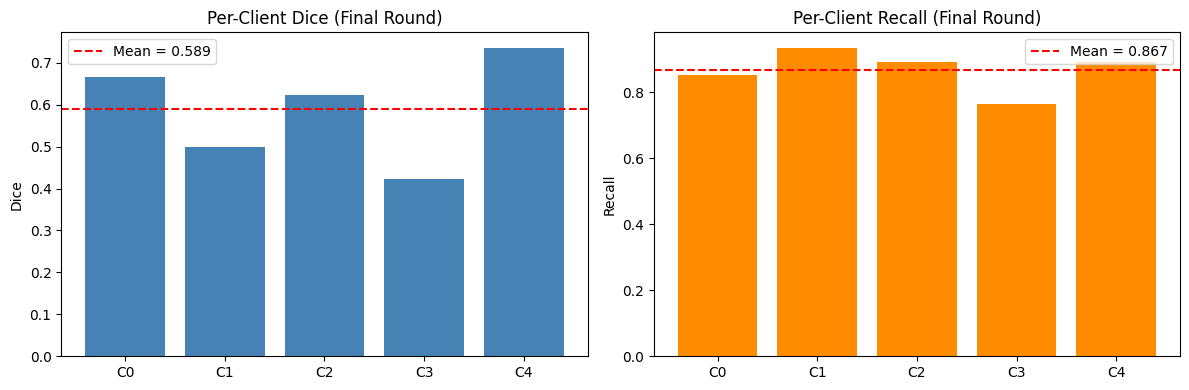

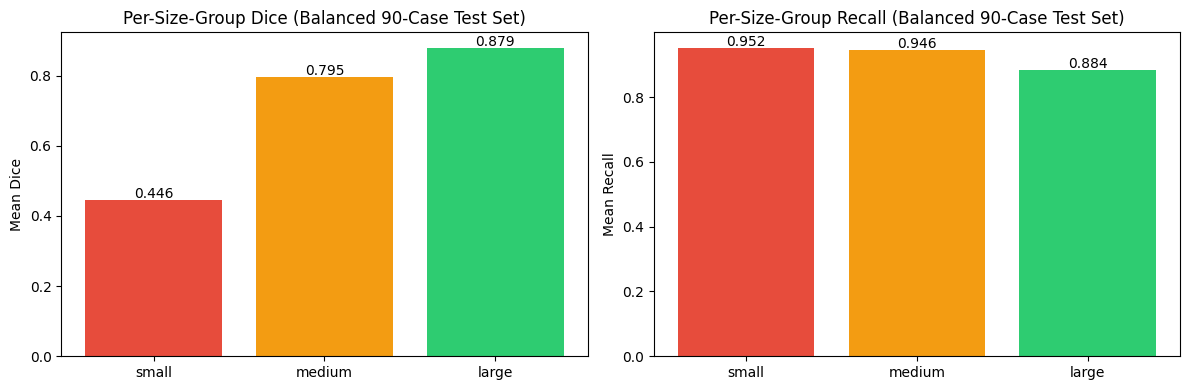

In [31]:
# ── Plot 1: Convergence curve ─────────────────────────────────────────────────
scores_df = pd.DataFrame(round_scores)

plt.figure(figsize=(10, 4))
plt.plot(scores_df["round"], scores_df["global_dice"],
         label="Global Dice (locked-box test)", marker="o", markersize=3)
plt.xlabel("Communication Round")
plt.ylabel("Dice Score")
plt.title("FedAvg Convergence Curve (R=100, E=1, Weighted Aggregation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedavg_checkpoints/convergence_curve.png', dpi=150)
plt.show()

# ── Plot 2: Per-client Dice & Recall ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(NUM_CLIENTS)
axes[0].bar(x, client_dice_scores,   color='steelblue')
axes[0].axhline(np.mean(client_dice_scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(client_dice_scores):.3f}')
axes[0].set_title("Per-Client Dice (Final Round)")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"C{i}" for i in x])
axes[0].set_ylabel("Dice")
axes[0].legend()

axes[1].bar(x, client_recall_scores, color='darkorange')
axes[1].axhline(np.mean(client_recall_scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(client_recall_scores):.3f}')
axes[1].set_title("Per-Client Recall (Final Round)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f"C{i}" for i in x])
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedavg_checkpoints/per_client_metrics.png', dpi=150)
plt.show()

# ── Plot 3: Per-size-group Dice & Recall ──────────────────────────────────────
groups     = ["small", "medium", "large"]
group_dice = [np.mean(size_results[g]["dice"])   if size_results[g]["dice"]   else 0 for g in groups]
group_rec  = [np.mean(size_results[g]["recall"]) if size_results[g]["recall"] else 0 for g in groups]
colors     = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(groups, group_dice, color=colors)
axes[0].set_title("Per-Size-Group Dice (Balanced 90-Case Test Set)")
axes[0].set_ylabel("Mean Dice")
for i, v in enumerate(group_dice):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

axes[1].bar(groups, group_rec, color=colors)
axes[1].set_title("Per-Size-Group Recall (Balanced 90-Case Test Set)")
axes[1].set_ylabel("Mean Recall")
for i, v in enumerate(group_rec):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedavg_checkpoints/per_size_metrics.png', dpi=150)
plt.show()


In [32]:
print("=" * 60)
print("  FEDAVG BASELINE — FINAL RESULTS SUMMARY")
print("=" * 60)

small_dice  = np.mean(size_results["small"]["dice"])
medium_dice = np.mean(size_results["medium"]["dice"])
large_dice  = np.mean(size_results["large"]["dice"])
small_rec   = np.mean(size_results["small"]["recall"])
medium_rec  = np.mean(size_results["medium"]["recall"])
large_rec   = np.mean(size_results["large"]["recall"])

print("\n-- Global Metrics (90-case balanced test set) --------")
print(f"  Mean Dice:              {global_dice_all:.4f}")
print(f"  Mean Recall:            {global_recall_all:.4f}")

print("\n-- Per-Size Metrics ----------------------------------")
print(f"  Small  Dice / Recall:   {small_dice:.4f}  /  {small_rec:.4f}   (n=30)")
print(f"  Medium Dice / Recall:   {medium_dice:.4f}  /  {medium_rec:.4f}   (n=30)")
print(f"  Large  Dice / Recall:   {large_dice:.4f}  /  {large_rec:.4f}   (n=30)")

worst_c_dice   = min(client_dice_scores)
worst_c_recall = min(client_recall_scores)
worst_c_idx_d  = int(np.argmin(client_dice_scores))
worst_c_idx_r  = int(np.argmin(client_recall_scores))

print("\n-- Fairness Metrics ----------------------------------")
print(f"  Worst-Client Dice:      {worst_c_dice:.4f}  (Client {worst_c_idx_d})")
print(f"  Worst-Client Recall:    {worst_c_recall:.4f}  (Client {worst_c_idx_r})")
print(f"  Small-Large Dice Gap:   {large_dice - small_dice:.4f}")
print(f"  Small-Large Recall Gap: {large_rec  - small_rec:.4f}")
print("=" * 60)


  FEDAVG BASELINE — FINAL RESULTS SUMMARY

-- Global Metrics (90-case balanced test set) --------
  Mean Dice:              0.7132
  Mean Recall:            0.9274

-- Per-Size Metrics ----------------------------------
  Small  Dice / Recall:   0.4463  /  0.9519   (n=30)
  Medium Dice / Recall:   0.7954  /  0.9465   (n=30)
  Large  Dice / Recall:   0.8791  /  0.8837   (n=30)

-- Fairness Metrics ----------------------------------
  Worst-Client Dice:      0.4228  (Client 3)
  Worst-Client Recall:    0.7637  (Client 3)
  Small-Large Dice Gap:   0.4329
  Small-Large Recall Gap: -0.0683
